# ANÁLISE DE CANCELAMENTOS (Otimizada e Corrigida V2)

Este notebook, `Analise1_Otimizada.ipynb`, é uma versão otimizada e corrigida de notebooks anteriores. As melhorias incluem:
1.  **Codificação Correta**: Ajuste para UTF-8 para corrigir problemas de caracteres (acentuação).
2.  **Carregamento Otimizado**: Uso de `usecols` para economia de memória.
3.  **Análises Completas**: Inclusão de análises Geográficas, por Unidade de Saúde e por Profissão.
    *   *Nota*: A análise por "Motivo" foi removida devido à inconsistência na tabela de ligação `tb_ms_motivo_inadequacao`.
4.  **Caminhos Relativos**: Uso de caminhos relativos (`./datasets1/`).

## Objetivo
Identificar padrões de cancelamento por localização, unidade e profissional.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Configurar visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_palette("viridis")
plt.style.use('ggplot')

## 1. Carregamento Otimizado dos Dados
Carregamos apenas as tabelas e colunas estritamente necessárias.

In [2]:
def load_dataset(path, usecols=None, dtype=None):
    try:
        # Ajuste: separador ',' e encoding UTF-8 (padrão)
        return pd.read_csv(path, sep=',', encoding='utf-8', low_memory=False, usecols=usecols, dtype=dtype)
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {path}")
        return pd.DataFrame()
    except UnicodeDecodeError:
        # Fallback se houver problema, mas a inspeção indicou UTF-8
        print(f"Erro de encoding em {path}, tentando latin1...")
        return pd.read_csv(path, sep=',', encoding='latin1', low_memory=False, usecols=usecols, dtype=dtype)

# Definição de Caminhos
path_datasets1 = "./datasets1/"

# 1. df_amostra: Tabela principal
cols_amostra = ['co_seq_amostra', 'co_seq_unidade_saude', 'dt_hr_cancelamento', 'aut_registro']
df_amostra = load_dataset(os.path.join(path_datasets1, "tb_amostra.csv"), usecols=cols_amostra)

# 2. df_unidade_saude: Link com Município e Nome da Unidade
cols_unidade = ['co_seq_unidade_saude', 'no_unidade_saude', 'co_seq_municipio']
df_unidade_saude = load_dataset(os.path.join(path_datasets1, "tb_unidade_saude.csv"), usecols=cols_unidade)

# 3. df_municipio: Nomes dos municípios
cols_municipio = ['co_seq_municipio', 'no_municipio']
df_municipio = load_dataset(os.path.join(path_datasets1, "tb_municipio.csv"), usecols=cols_municipio)

# 4. df_profissao: Nomes das profissões
cols_profissao_tab = ['co_seq_profissao', 'no_profissao']
df_profissao = load_dataset(os.path.join(path_datasets1, "tb_profissao.csv"), usecols=cols_profissao_tab)

# 5. df_profissional_saude: Link Amostra (aut_registro) <-> Profissão
cols_profissional = ['co_seq_prof_saude', 'aut_registro', 'co_seq_profissao']
df_profissional_saude = load_dataset(os.path.join(path_datasets1, "tb_profissional_saude.csv"), usecols=cols_profissional, dtype={'aut_registro': str})

# Tratamento inicial de tipos
if 'aut_registro' in df_amostra.columns:
    df_amostra['aut_registro'] = df_amostra['aut_registro'].astype(str)

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


## 2. Preparação dos Dados (Merge Principal)
Criamos um dataset mestre de cancelamentos com informações geográficas e de unidade.

In [3]:
# Filtrar amostras canceladas
df_canceladas = df_amostra[df_amostra['dt_hr_cancelamento'].notna()].copy()
print(f"Total de Amostras Canceladas: {len(df_canceladas)}")

# Merge 1: Adicionar dados da Unidade de Saúde (Nome e ID Município)
df_canceladas = df_canceladas.merge(
    df_unidade_saude[['co_seq_unidade_saude', 'no_unidade_saude', 'co_seq_municipio']],
    on='co_seq_unidade_saude',
    how='left'
)

# Merge 2: Adicionar nome do Município
df_canceladas = df_canceladas.merge(
    df_municipio,
    on='co_seq_municipio',
    how='left'
)

Total de Amostras Canceladas: 596


## 3. Análise Geográfica (Municípios)
Municípios com maior volume de cancelamentos.

Top 15 Municípios com mais Cancelamentos:
no_municipio
São Luís                   127
Açailândia                  50
Imperatriz                  27
Balsas                      25
Caxias                      20
Bacabal                     15
Alto Alegre do Maranhão     11
Grajaú                       8
Viana                        7
Araioses                     7
Mirador                      7
Coroatá                      7
Parnarama                    6
Porto Franco                 6
Timbiras                     5
Name: count, dtype: int64


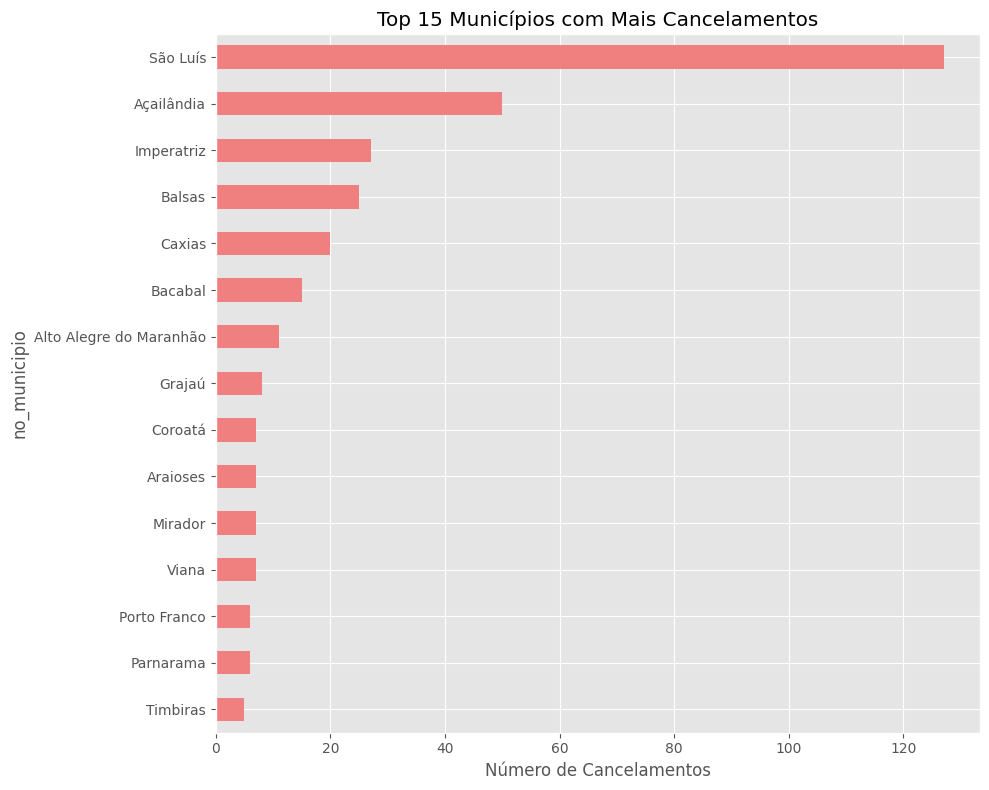

In [4]:
# Contagem por Município
top_municipios = df_canceladas['no_municipio'].value_counts().head(15)

print("Top 15 Municípios com mais Cancelamentos:")
print(top_municipios)

# Visualização
if not top_municipios.empty:
    plt.figure(figsize=(10, 8))
    top_municipios.sort_values().plot(kind='barh', color='lightcoral')
    plt.title('Top 15 Municípios com Mais Cancelamentos')
    plt.xlabel('Número de Cancelamentos')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado geográfico disponível.")

## 4. Análise por Unidade de Saúde
Unidades de saúde com maior volume de cancelamentos.

Top 15 Unidades de Saúde com mais Cancelamentos:
no_unidade_saude
SEC.MUNIC. DE ACAILANDIA                          48
APAE                                              28
MAT. MATERNO INFANTIL                             27
HOSP. INF. DR. JUVENCIO MATTOS                    25
MAC-MA                                            23
SOC MED. HOSP.C.REI                               19
HOSP.MATER-INF                                    15
MATERNIDADE DE ALTO RISCO DE IMPERATRIZ - MARI    12
HOSP. REG. DE ALTO ALEGRE                         11
MAT. CARMOS.COUTINHO                               8
U.B.S. VIANA                                       7
MAT. BENEDITO LEITE COHAB                          7
HOSP. SANTA NEUSA                                  6
HOSPITAL REGIONAL DE BALSAS                        6
U.B.S. RAIMUNDO MARÇAL                             5
Name: count, dtype: int64


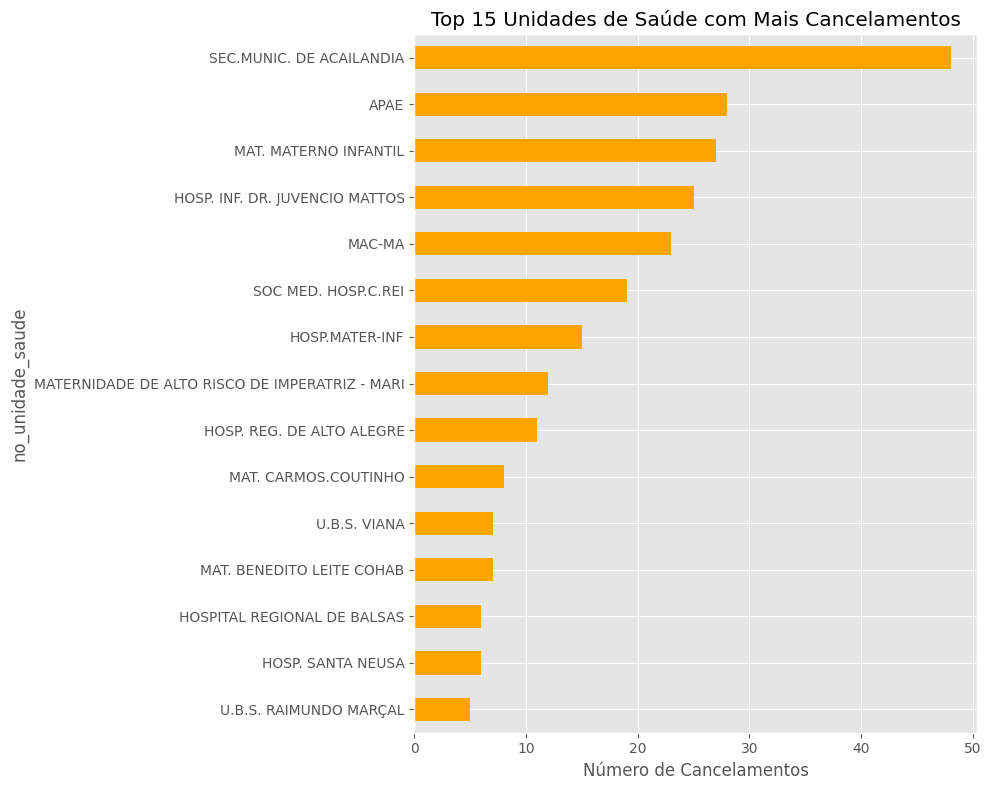

In [5]:
# Contagem por Unidade de Saúde
top_unidades = df_canceladas['no_unidade_saude'].value_counts().head(15)

print("Top 15 Unidades de Saúde com mais Cancelamentos:")
print(top_unidades)

# Visualização
if not top_unidades.empty:
    plt.figure(figsize=(10, 8))
    top_unidades.sort_values().plot(kind='barh', color='orange')
    plt.title('Top 15 Unidades de Saúde com Mais Cancelamentos')
    plt.xlabel('Número de Cancelamentos')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado de unidade disponível.")

## 5. Análise por Profissão (Taxa de Cancelamento)
Ranking de profissões com maior percentual de amostras canceladas.


⚠️ AVISO: DADOS INCOMPLETOS. Esta análise considera apenas 7 profissionais (de >20 ativos) devido à falta de mapeamento de usuários.

Ranking (Parcial): Taxa de Cancelamento por Profissão (Min. 5 amostras):
                               Total_Amostras  Total_Cancelamentos  \
no_profissao                                                         
FARMACÊUTICO ANALISTA CLINICO              11                   11   

                               Taxa_Cancelamento  
no_profissao                                      
FARMACÊUTICO ANALISTA CLINICO              100.0  


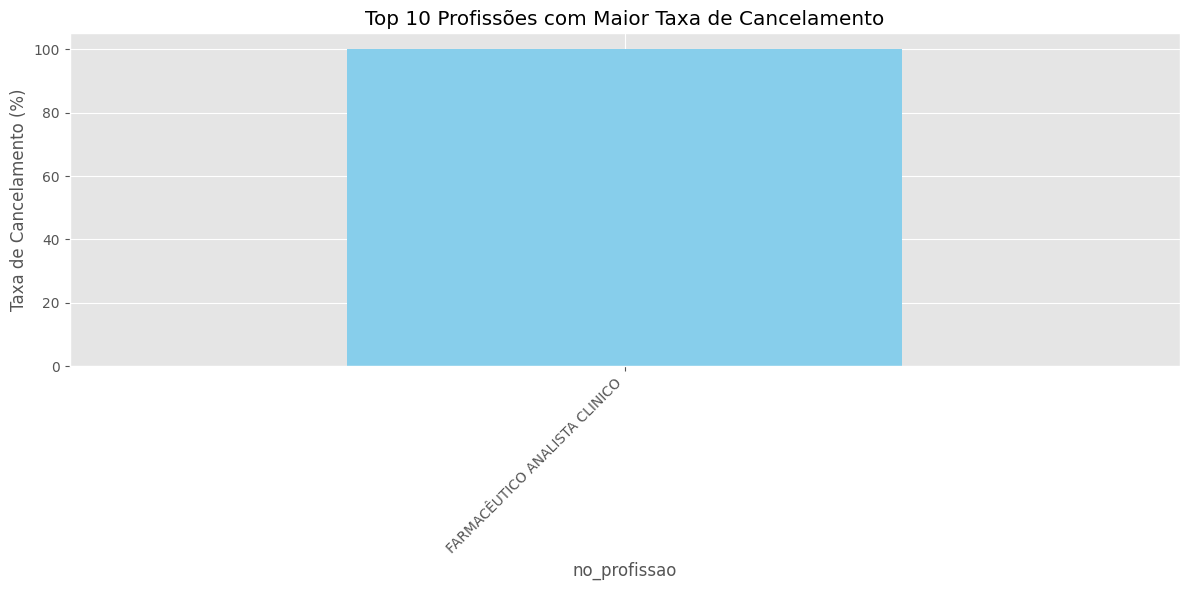

In [ ]:
# 1. Criar lookup de Profissional -> Profissão
df_lookup_prof = df_profissional_saude.merge(
    df_profissao,
    on='co_seq_profissao',
    how='left'
)

# 2. Unir TODAS Amostras (não só canceladas) com Profissão
df_amostras_prof = df_amostra.merge(
    df_lookup_prof[['aut_registro', 'no_profissao']],
    on='aut_registro',
    how='left'
)

# 3. Calcular KPI
# Denominador: Total de amostras por profissão
total_por_prof = df_amostras_prof.groupby('no_profissao').size().rename('Total_Amostras')

# Numerador: Cancelados por profissão
cancelados_por_prof = (
    df_amostras_prof[df_amostras_prof['dt_hr_cancelamento'].notna()]
    .groupby('no_profissao')
    .size()
    .rename('Total_Cancelamentos')
)

# 4. Juntar e Calcular Taxa
df_kpi = pd.concat([total_por_prof, cancelados_por_prof], axis=1).fillna(0)
df_kpi['Taxa_Cancelamento'] = (df_kpi['Total_Cancelamentos'] / df_kpi['Total_Amostras']) * 100

# Filtrar para relevância estatística (min. 5 amostras)
df_kpi_filtered = df_kpi[df_kpi['Total_Amostras'] >= 5].sort_values('Taxa_Cancelamento', ascending=False)

print("\n⚠️ AVISO: DADOS INCOMPLETOS. Esta análise considera apenas 7 profissionais (de >20 ativos) devido à falta de mapeamento de usuários.\n")
print("Ranking (Parcial): Taxa de Cancelamento por Profissão (Min. 5 amostras):")
print(df_kpi_filtered.head(10))

# Gráfico
if not df_kpi_filtered.empty:
    plt.figure(figsize=(12, 6))
    df_kpi_filtered['Taxa_Cancelamento'].head(10).plot(kind='bar', color='skyblue')
    plt.title('Top 10 Profissões com Maior Taxa de Cancelamento')
    plt.ylabel('Taxa de Cancelamento (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()